## ResNet Comparison Notebook

This notebook implements a ResNet-based model using the same data pipeline and training setup as the CNN notebook. The goal is to ensure a fair comparison between architectures by keeping everything constant except the model itself.

In [49]:
import sys
from pathlib import Path
import math, re, os

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

print("TensorFlow version:", tf.__version__)
print("Project root:", PROJECT_ROOT)

TensorFlow version: 2.21.0
Project root: C:\Users\nater\KaggleFlowerChallenge


In [50]:
strategy = tf.distribute.get_strategy()
print("REPLICAS:", strategy.num_replicas_in_sync)

REPLICAS: 1


## Dataset Setup

In this section, we load the TFRecord file paths for the training, validation, and test sets. These datasets are identical to those used in the CNN implementation.

In [51]:
IMAGE_SIZE = 64
AUTO = tf.data.AUTOTUNE

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "tfrecords-jpeg-224x224"

TRAINING_FILENAMES = tf.io.gfile.glob(str(DATA_DIR / "train" / "*.tfrec"))
VALIDATION_FILENAMES = tf.io.gfile.glob(str(DATA_DIR / "val" / "*.tfrec"))
TEST_FILENAMES = tf.io.gfile.glob(str(DATA_DIR / "test" / "*.tfrec"))

print("Train files:", len(TRAINING_FILENAMES))
print("Val files:", len(VALIDATION_FILENAMES))
print("Test files:", len(TEST_FILENAMES))

Train files: 16
Val files: 16
Test files: 16


In [52]:
CLASSES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',
    'wild geranium', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood',
    'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle',
    'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily',
    'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower',
    'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy',
    'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william',
    'carnation', 'garden phlox', 'love in the mist', 'cosmos', 'alpine sea holly',
    'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip',
    'lenten rose', 'barberton daisy', 'daffodil', 'sword lily', 'poinsettia',
    'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'daisy',
    'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower',
    'lilac hibiscus', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
    'pink-yellow dahlia', 'cautleya spicata', 'japanese anemone',
    'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
    'spring crocus', 'iris', 'windflower', 'tree poppy', 'gazania', 'azalea',
    'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower',
    'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus',
    'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ',
    'watercress', 'canna lily', 'hippeastrum ', 'bee balm', 'pink quill',
    'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia',
    'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily',
    'common tulip', 'wild rose'
]

NUM_CLASSES = len(CLASSES)
print(NUM_CLASSES)

104


## TFRecord Parsing

These functions convert raw TFRecord data into usable image and label pairs. Images are decoded, resized, and normalized for training.

In [53]:
def decode_image(image_data):
    image = tf.image.decode_jpeg(image_data, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image


def read_labeled_tfrecord(example):
    labeled_format = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "class": tf.io.FixedLenFeature([], tf.int64),
    }
    example = tf.io.parse_single_example(example, labeled_format)
    image = decode_image(example["image"])
    label = tf.cast(example["class"], tf.int32)
    return image, label


def read_unlabeled_tfrecord(example):
    unlabeled_format = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "id": tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, unlabeled_format)
    image = decode_image(example["image"])
    idnum = example["id"]
    return image, idnum


def load_dataset(filenames, labeled=True, ordered=False):
    options = tf.data.Options()
    if not ordered:
        options.experimental_deterministic = False

    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=AUTO)
    dataset = dataset.with_options(options)
    dataset = dataset.map(
        read_labeled_tfrecord if labeled else read_unlabeled_tfrecord,
        num_parallel_calls=AUTO
    )
    return dataset

## Dataset Pipeline and Augmentation

Here we build the TensorFlow datasets with batching, shuffling, and prefetching. We also apply simple augmentation (random horizontal flips) to improve generalization. This setup matches the CNN pipeline to ensure a fair comparison.

In [54]:
def data_augment(image, label):
    image = tf.image.random_flip_left_right(image)
    return image, label


def count_data_items(filenames):
    counts = [
        int(re.compile(r"-([0-9]*)\.").search(filename).group(1))
        for filename in filenames
    ]
    return np.sum(counts)


NUM_TRAINING_IMAGES = count_data_items(TRAINING_FILENAMES)
NUM_VALIDATION_IMAGES = count_data_items(VALIDATION_FILENAMES)
NUM_TEST_IMAGES = count_data_items(TEST_FILENAMES)

print("Training images:", NUM_TRAINING_IMAGES)
print("Validation images:", NUM_VALIDATION_IMAGES)
print("Test images:", NUM_TEST_IMAGES)


BATCH_SIZE = 16 * strategy.num_replicas_in_sync
print("Batch size:", BATCH_SIZE)


def get_training_dataset():
    dataset = load_dataset(TRAINING_FILENAMES, labeled=True)
    dataset = dataset.map(data_augment, num_parallel_calls=AUTO)
    dataset = dataset.repeat()
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO)
    return dataset


def get_validation_dataset(ordered=False):
    dataset = load_dataset(VALIDATION_FILENAMES, labeled=True, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.cache()
    dataset = dataset.prefetch(AUTO)
    return dataset


def get_test_dataset(ordered=False):
    dataset = load_dataset(TEST_FILENAMES, labeled=False, ordered=ordered)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTO)
    return dataset


ds_train = get_training_dataset()
ds_valid = get_validation_dataset()
ds_test = get_test_dataset()

STEPS_PER_EPOCH = NUM_TRAINING_IMAGES // BATCH_SIZE
print("Steps per epoch:", STEPS_PER_EPOCH)

Training images: 12753
Validation images: 3712
Test images: 7382
Batch size: 16
Steps per epoch: 797


## Sanity Check

We visualize a sample image and label to confirm that the dataset is being loaded and processed correctly.

(16, 64, 64, 3) (16,)


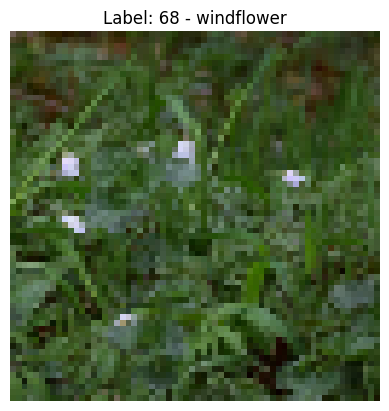

In [55]:
for images, labels in ds_train.take(1):
    print(images.shape, labels.shape)
    plt.imshow(images[0].numpy())
    plt.title(f"Label: {labels[0].numpy()} - {CLASSES[labels[0].numpy()]}")
    plt.axis("off")
    plt.show()

## ResNet Model

This section defines a small ResNet-style architecture using residual (skip) connections. These connections allow deeper networks to train more effectively by preserving information across layers.

In [ ]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, strides=1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.ReLU()(x)

    return x


def build_basic_resnet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(16, 3, padding="same", use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 16, stride=1)
    x = residual_block(x, 32, stride=2)
    x = residual_block(x, 64, stride=2)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="resnet")

## Model Compilation

We compile the model using the same optimizer, loss function, and metrics as the CNN baseline to ensure a fair comparison.

In [57]:
with strategy.scope():
    model = build_basic_resnet()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"]
    )

model.summary()

Model: "basic_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │        432 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 64, 64,    │      2,304 │ re_lu_21[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │      2,304 │ re_lu_22[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ re_lu_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_23 (ReLU)     │ (None, 64, 64,    │          0 │ add_9[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │      4,608 │ re_lu_23[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 32, 32,    │      9,216 │ re_lu_24[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 32, 32,    │        512 │ re_lu_23[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_31[0][0] 

 Total params: 84,824 (331.34 KB)

 Trainable params: 84,152 (328.72 KB)

 Non-trainable params: 672 (2.62 KB)

## Learning Rate Schedule

A custom learning rate schedule is used to gradually increase the learning rate and then decay it. This helps stabilize training and improve convergence.

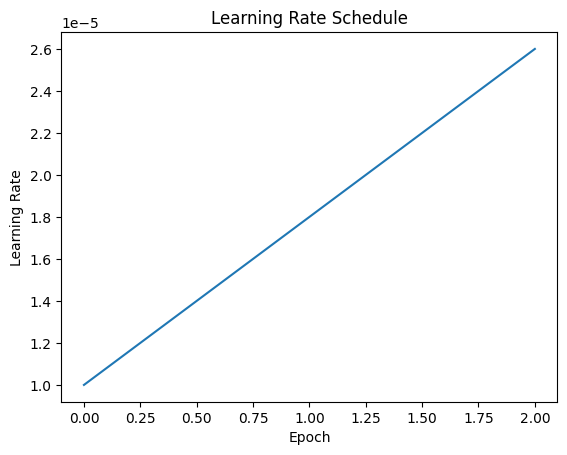

In [58]:
EPOCHS = 3

def exponential_lr(epoch,
                   start_lr=0.00001,
                   min_lr=0.00001,
                   max_lr=0.00005,
                   rampup_epochs=5,
                   sustain_epochs=0,
                   exp_decay=0.8):

    if epoch < rampup_epochs:
        lr = ((max_lr - start_lr) / rampup_epochs * epoch + start_lr)
    elif epoch < rampup_epochs + sustain_epochs:
        lr = max_lr
    else:
        lr = ((max_lr - min_lr) *
              exp_decay ** (epoch - rampup_epochs - sustain_epochs) +
              min_lr)
    return lr


lr_callback = tf.keras.callbacks.LearningRateScheduler(exponential_lr, verbose=True)

rng = [i for i in range(EPOCHS)]
y = [exponential_lr(x) for x in rng]

plt.plot(rng, y)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

## Training

We train the ResNet model using the same setup as the CNN baseline, including batch size and steps per epoch. This ensures that any performance differences are due to the model architecture.

In [59]:
TEST_RUN = False

if TEST_RUN:
    history_resnet = model.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=1,
        steps_per_epoch=25,
        validation_steps=10,
        callbacks=[lr_callback],
    )
else:
    history_resnet = model.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS,
        steps_per_epoch=STEPS_PER_EPOCH,
        callbacks=[lr_callback],
    )


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - loss: 3.5799 - sparse_categorical_accuracy: 0.1535 - val_loss: 3.3844 - val_sparse_categorical_accuracy: 0.1802 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0008100000379979611.
Epoch 2/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - loss: 3.1396 - sparse_categorical_accuracy: 0.2116 - val_loss: 2.9915 - val_sparse_categorical_accuracy: 0.2196 - learning_rate: 8.1000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0005060000335611404.
Epoch 3/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - loss: 2.9223 - sparse_categorical_accuracy: 0.2493 - val_loss: 3.0222 - val_sparse_categorical_accuracy: 0.2376 - learning_rate: 5.0600e-04


## Saving the Model

The trained ResNet model is saved so it can be reused later for evaluation or comparison.

In [60]:
model.save("../src/models/resnet_3epochs.keras")

## Training Curves

We visualize training and validation performance over time to understand how the model is learning.

In [61]:
import matplotlib.pyplot as plt

# Accuracy plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_resnet.history["sparse_categorical_accuracy"], marker="o", label="train acc")
ax.plot(history_resnet.history["val_sparse_categorical_accuracy"], marker="o", label="val acc")
ax.set_title("ResNet Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
fig.savefig("../outputs/figures/resnet_3epochs_accuracy.png", bbox_inches="tight")
plt.close(fig)

# Loss plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_resnet.history["loss"], marker="o", label="train loss")
ax.plot(history_resnet.history["val_loss"], marker="o", label="val loss")
ax.set_title("ResNet Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
fig.savefig("../outputs/figures/resnet_3epochs_loss.png", bbox_inches="tight")
plt.close(fig)

print("Saved ResNet accuracy and loss plots.")

Saved ResNet accuracy and loss plots.


## Evaluation Metrics

In addition to accuracy, we compute metrics such as F1-score, precision, and recall to get a more complete picture of model performance.

In [62]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

cmdataset = get_validation_dataset(ordered=True)
images_ds = cmdataset.map(lambda image, label: image)
labels_ds = cmdataset.map(lambda image, label: label).unbatch()

cm_correct_labels = next(iter(labels_ds.batch(NUM_VALIDATION_IMAGES))).numpy()

cm_probabilities = model.predict(images_ds)
cm_predictions = np.argmax(cm_probabilities, axis=-1)

labels = range(len(CLASSES))

score = f1_score(cm_correct_labels, cm_predictions, labels=labels, average="macro")
precision = precision_score(cm_correct_labels, cm_predictions, labels=labels, average="macro")
recall = recall_score(cm_correct_labels, cm_predictions, labels=labels, average="macro")

print("Macro F1:", score)
print("Macro precision:", precision)
print("Macro recall:", recall)

232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Macro F1: 0.0882587636365887
Macro precision: 0.13938157438449347
Macro recall: 0.09653847254188527


c:\Users\nater\KaggleFlowerChallenge\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Kaggle Submission

We generate predictions on the test set and format them into a CSV file suitable for submission to Kaggle.

In [ ]:
test_ds = get_test_dataset(ordered=True)

print("Computing predictions...")
test_images_ds = test_ds.map(lambda image, idnum: image)

probabilities = model.predict(test_images_ds)
predictions = np.argmax(probabilities, axis=-1)

test_ids_ds = test_ds.map(lambda image, idnum: idnum).unbatch()
test_ids = next(iter(test_ids_ds.batch(NUM_TEST_IMAGES))).numpy().astype("U")

submission_path = "../outputs/submissions/resnet3_submission.csv"

np.savetxt(
    submission_path,
    np.rec.fromarrays([test_ids, predictions]),
    fmt=["%s", "%d"],
    delimiter=",",
    header="id,label",
    comments=""
)

print("Saved:", submission_path)

Computing predictions...
462/462 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step


c:\Users\nater\KaggleFlowerChallenge\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Saved: ../outputs/submissions/resnet_submission.csv


In [64]:
print(history_resnet.history.keys())
print(history_resnet.history)

dict_keys(['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy', 'learning_rate'])
{'loss': [3.57989239692688, 3.1396143436431885, 2.922293186187744], 'sparse_categorical_accuracy': [0.1534661203622818, 0.21157465875148773, 0.2492942214012146], 'val_loss': [3.384389877319336, 2.9915435314178467, 3.022195816040039], 'val_sparse_categorical_accuracy': [0.18022629618644714, 0.21955819427967072, 0.23760776221752167], 'learning_rate': [0.0010000000474974513, 0.0008100000559352338, 0.000506000011228025]}
